In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive/uss/Hackathon1")

['Offroad_Segmentation_Training_Dataset']

In [ ]:
os.listdir("/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset")

['train']

In [ ]:
os.listdir("/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train")

['Color_Images']

In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive/uss/Hackathon1"):
    print(root)

/content/drive/MyDrive/uss/Hackathon1
/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset
/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train
/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images
/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask


In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"
mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
import os

print(len(os.listdir(image_dir)))
print(len(os.listdir(mask_dir)))

1089
2856


In [ ]:
!pip install torch torchvision
!pip install opencv-python

In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import os

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.resize(image,(512,512))

        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask,(512,512))

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
import torch
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
)

model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

model = model.to(device)

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
for epoch in range(10):

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

IndexError: Target 39 is out of bounds.

In [ ]:
import numpy as np
import cv2
import os

mask_path = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

sample_mask = cv2.imread(os.path.join(mask_path, os.listdir(mask_path)[0]),0)

print(np.unique(sample_mask))

[ 0  1  2  3 27 39]


In [ ]:
mask = cv2.imread(mask_path,0)
mask = cv2.resize(mask,(512,512))

mask[mask > 0] = 1

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
import os

print(os.listdir(mask_dir)[:10])

['cc0000013.png', 'cc0000026.png', 'cc0000015.png', 'cc0000182.png', 'cc0000151.png', 'cc0000135.png', 'cc0000129.png', 'cc0000156.png', 'cc0000159.png', 'cc0000158.png']


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        # keep only files that exist in both
        self.images = list(image_files & mask_files)

        print("Total matched pairs:", len(self.images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image, (512,512))
        mask = cv2.resize(mask, (512,512))

        # convert mask to binary
        mask[mask > 0] = 1

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

Total matched pairs: 1088


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
)

# 2 classes → background + offroad
model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 169MB/s]


In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
for epoch in range(10):

    model.train()
    running_loss = 0

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch, "Loss:", running_loss/len(dataloader))

NameError: name 'dataloader' is not defined

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

NameError: name 'OffroadDataset' is not defined

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = os.listdir(image_dir)

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.resize(image,(512,512))

        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask,(512,512))

        mask[mask > 0] = 1

        image = self.transform(image)
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"

mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

print(len(dataset))

1089


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
img, mask = dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([3, 512, 512])
torch.Size([512, 512])


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
import torch
from torchvision.models.segmentation import deeplabv3_resnet50

model = deeplabv3_resnet50(weights="DEFAULT")

model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        self.images = list(image_files & mask_files)   # only matching pairs

        print("Total matched pairs:", len(self.images))

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path,0)

        if image is None or mask is None:
            raise ValueError(f"Image or mask missing: {img_name}")

        image = cv2.resize(image,(512,512))
        mask = cv2.resize(mask,(512,512))

        mask[mask > 0] = 1

        image = self.transform(image)
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

Total matched pairs: 1088


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
for epoch in range(5):

    model.train()
    running_loss = 0

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(dataloader))

Epoch: 1 Loss: 0.0750276656163966


In [ ]:
loss.backward()

NameError: name 'loss' is not defined

In [ ]:
import torch
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
)

# change classifier for 2 classes
model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 188MB/s]


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"
mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)
print(len(dataset))

NameError: name 'OffroadDataset' is not defined

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        # keep only files that exist in both folders
        self.images = list(image_files & mask_files)

        print("Matched pairs:", len(self.images))

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image,(512,512))
        mask = cv2.resize(mask,(512,512))

        mask[mask > 0] = 1

        image = self.transform(image)
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"

mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

print(len(dataset))

Matched pairs: 1088
1088


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
import torch
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
)

# change classifier for 2 classes
model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

model = model.to(device)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(dataloader))

Epoch: 1 Loss: 0.15936728809302783
Epoch: 2 Loss: 0.045038190766182894
Epoch: 3 Loss: 0.030225556285586208
Epoch: 4 Loss: 0.0245014510326334
Epoch: 5 Loss: 0.021945935061119276


In [ ]:
model.eval()

img, mask = dataset[10]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))['out']
    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

NameError: name 'model' is not defined

In [ ]:
import torch
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
)

model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 164MB/s]


In [ ]:
torch.save(model.state_dict(), "offroad_segmentation_model.pth")

In [ ]:
img, mask = dataset[10]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))['out']
    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

NameError: name 'dataset' is not defined

In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"

mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

print(len(dataset))

NameError: name 'OffroadDataset' is not defined

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class OffroadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        # keep only matching files
        self.images = list(image_files & mask_files)

        print("Matched pairs:", len(self.images))

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image,(512,512))
        mask = cv2.resize(mask,(512,512))

        mask[mask > 0] = 1

        image = self.transform(image)
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
image_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/Color_Images"

mask_dir = "/content/drive/MyDrive/uss/Hackathon1/Offroad_Segmentation_Training_Dataset/train/mask"

In [ ]:
dataset = OffroadDataset(image_dir, mask_dir)

print(len(dataset))

Matched pairs: 1088
1088


In [ ]:
img, mask = dataset[10]

print(img.shape)
print(mask.shape)

torch.Size([3, 512, 512])
torch.Size([512, 512])


In [ ]:
model.eval()

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))['out']
    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

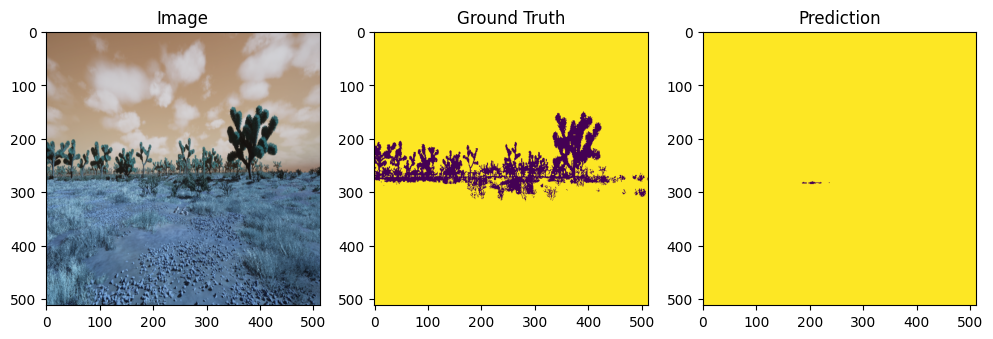

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask)

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred)

plt.show()

In [ ]:
num_epochs = 20

In [ ]:
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.2,0.8]).to(device))

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [ ]:
batch_size = 8

In [ ]:
model.eval()

img, mask = dataset[10]

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))['out']
    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

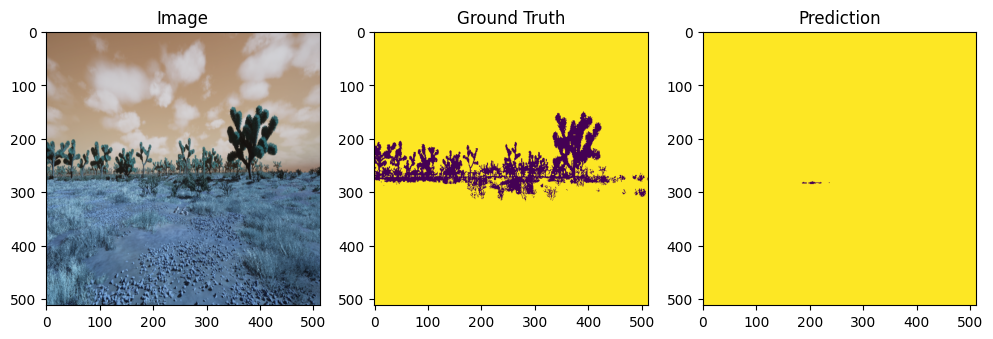

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask)

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred)

plt.show()

In [ ]:
import numpy as np

mask_np = mask.cpu().numpy()      # convert tensor to numpy
pred_np = pred                    # pred is already numpy

intersection = np.logical_and(mask_np, pred_np)
union = np.logical_or(mask_np, pred_np)

iou_score = intersection.sum() / union.sum()

print("IoU Score:", iou_score)

IoU Score: 0.9155184321686274


In [ ]:
iou_score = intersection.sum() / (union.sum() + 1e-6)

In [ ]:
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.2,0.8]).to(device))

In [25]:
import numpy as np

model.eval()

total_intersection = 0
total_union = 0

with torch.no_grad():

    for img, mask in dataset:

        img = img.unsqueeze(0).to(device)

        pred = model(img)['out']
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

        mask_np = mask.cpu().numpy()

        intersection = np.logical_and(mask_np, pred)
        union = np.logical_or(mask_np, pred)

        total_intersection += intersection.sum()
        total_union += union.sum()

iou_score = total_intersection / (total_union + 1e-6)

print("Dataset IoU Score:", iou_score)

Dataset IoU Score: 0.9796610581411282


In [26]:
import torch

torch.save(model.state_dict(), "/content/offroad_model.pth")

In [27]:
from google.colab import files
files.download("/content/offroad_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

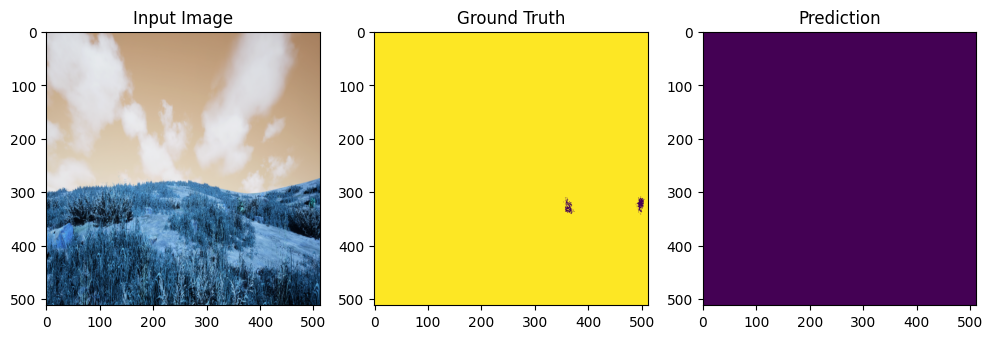

In [28]:
import matplotlib.pyplot as plt

model.eval()

img, mask = dataset[20]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))['out']
    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask)

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred)

plt.savefig("/content/prediction_result.png")
plt.show()

In [29]:
files.download("/content/prediction_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.savefig("/content/loss_graph.png")
plt.show()

NameError: name 'losses' is not defined